Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


Load the data

In [3]:
df = pd.read_csv("auto-mpg.csv")
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [5]:
df.shape

(398, 9)

In [6]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [8]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [9]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [10]:

df["horsepower"] = df["horsepower"].replace("?", np.nan)

df["horsepower"] = df["horsepower"].astype(float)

df["horsepower"].fillna(df["horsepower"].mean(), inplace=True)


C:\Users\jayas\AppData\Local\Temp\ipykernel_15688\1792763723.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].fillna(df["horsepower"].mean(), inplace=True)


In [11]:
print(df["horsepower"].dtype)
print(df["horsepower"].isnull().sum())


float64
0


Feature selection

In [12]:
X = df[["horsepower"]]
y = df["mpg"]


Split train and test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature scaling

In [14]:
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

Model training with polynomial regression

In [15]:
degrees = [2, 3, 4]

results = {}
models = {}
polys = {}

for d in degrees:
    
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[d] = (mse, rmse, r2)
    
    # STORE THEM
    models[d] = model
    polys[d] = poly
    
    print(f"\nDegree {d}")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)



Degree 2
MSE: 13.760855128148446
RMSE: 3.709562659957161
R2 Score: 0.7440623896917407



Degree 3
MSE: 13.813374257336637
RMSE: 3.716634802793602
R2 Score: 0.7430855884468529

Degree 4
MSE: 14.118024022067797
RMSE: 3.757395909678377
R2 Score: 0.7374194192996484


Comparison table

In [16]:
comparison_df = pd.DataFrame(results, 
                             index=["MSE", "RMSE", "R2"]).T

comparison_df


,MSE,RMSE,R2
2,13.760855,3.709563,0.744062
3,13.813374,3.716635,0.743086
4,14.118024,3.757396,0.737419


Polynomial Curve Fitting Visualization

c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


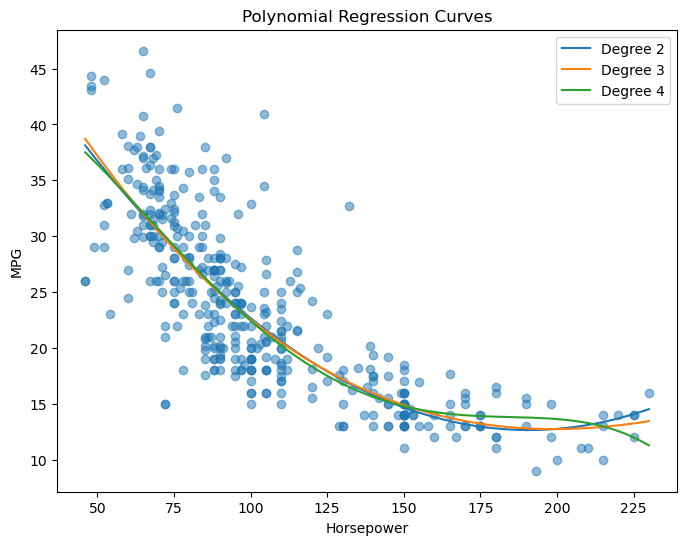

In [17]:
X_range = np.linspace(df["horsepower"].min(),
                      df["horsepower"].max(), 300).reshape(-1, 1)

plt.figure(figsize=(8,6))
plt.scatter(df["horsepower"], df["mpg"], alpha=0.5)

for d in degrees:
    
    # Apply polynomial transformation directly (NO SCALING)
    X_range_poly = polys[d].transform(X_range)
    
    # Predict using trained model
    y_curve = models[d].predict(X_range_poly)
    
    plt.plot(X_range, y_curve, label=f"Degree {d}")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression Curves")
plt.legend()
plt.show()



Training vs Testing Error (Overfitting Demonstration)

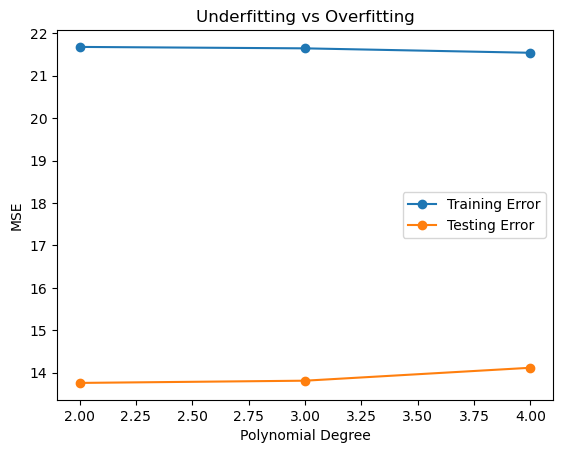

In [18]:
train_errors = []
test_errors = []

for d in degrees:
    poly = PolynomialFeatures(d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_errors.append(mean_squared_error(
        y_train, model.predict(X_train_poly)))
    
    test_errors.append(mean_squared_error(
        y_test, model.predict(X_test_poly)))

plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Underfitting vs Overfitting")
plt.legend()
plt.show()


Apply Ridge Regression (Degree 4)

In [20]:
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=0.7)
ridge.fit(X_train_poly, y_train)

y_pred_ridge = ridge.predict(X_test_poly)

print("\nRidge Regression (Degree 4)")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))



Ridge Regression (Degree 4)
MSE: 14.11764655854534
RMSE: 3.757345679937546
R2 Score: 0.7374264397290486


c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.32946e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [24]:
from sklearn.pipeline import Pipeline


for d in [2,3,4]:
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(d)),
        ("ridge", Ridge(alpha=0.5))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\nDegree {d} with Ridge")
    print("R2:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



Degree 2 with Ridge
R2: 0.7442947133944102
RMSE: 3.7078786265002086

Degree 3 with Ridge
R2: 0.7432544194075101
RMSE: 3.715413411316055

Degree 4 with Ridge
R2: 0.738418925927559
RMSE: 3.7502378731462467
